# Hidden-Dim Ablation — Actor-Critic (256 / 128 / 64)

This notebook trains **Actor-Critic only** with three hidden layer sizes (`256`, `128`, `64`) and compares reward learning curves.

## Outputs
For each `hidden_dim`, artifacts are written to:
- `../artifacts/hidden_dim_sweep/hd_<hidden_dim>/agent_actor_critic/`

Each run folder contains:
- `train_log_actor_critic.csv`
- `actor_critic_model.pt`
- `checkpoints/`

Set `RUN_TRAINING=False` to skip training and only re-plot existing logs.

In [1]:
from __future__ import annotations

from pathlib import Path
import subprocess
import sys

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# ------------------- user params -------------------
HIDDEN_DIMS = [256, 128, 64]
AGENTS = ['actor_critic']
STEPS_PER_RUN = 500_000
SEED = 420
DEVICE = 'cpu'
RUN_TRAINING = True
WINDOW = 100
# ---------------------------------------------------

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'run').exists() and (PROJECT_ROOT.parent / 'run').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

BASE_OUTDIR = PROJECT_ROOT / 'artifacts' / 'hidden_dim_sweep'
BASE_OUTDIR.mkdir(parents=True, exist_ok=True)

results: dict[tuple[str, int], pd.DataFrame] = {}


In [2]:
def train_combo(agent: str, hidden_dim: int) -> Path:
    run_dir = BASE_OUTDIR / f'hd_{hidden_dim}' / f'agent_{agent}'
    run_dir.mkdir(parents=True, exist_ok=True)

    log_csv = run_dir / f'train_log_{agent}.csv'

    if not RUN_TRAINING and log_csv.exists():
        print(f"[skip] agent={agent} hidden_dim={hidden_dim} (CSV exists): {log_csv}")
        return log_csv

    print(f"[train] agent={agent} hidden_dim={hidden_dim} steps={STEPS_PER_RUN} -> {run_dir}")
    cmd = [
        sys.executable,
        '-m',
        'run.train',
        '--agent',
        agent,
        '--steps',
        str(STEPS_PER_RUN),
        '--seed',
        str(SEED),
        '--device',
        DEVICE,
        '--hidden-dim',
        str(hidden_dim),
        '--artifacts-dir',
        str(run_dir),
    ]

    subprocess.run(cmd, check=True, cwd=str(PROJECT_ROOT))

    if not log_csv.exists():
        raise FileNotFoundError(f"Expected training log not found: {log_csv}")

    return log_csv


for hidden_dim in HIDDEN_DIMS:
    for agent in AGENTS:
        csv_path = train_combo(agent, hidden_dim)
        df = pd.read_csv(csv_path)
        if 'episode' not in df.columns:
            df['episode'] = range(1, len(df) + 1)
        results[(agent, hidden_dim)] = df
        print(f"- agent={agent:18s} hidden_dim={hidden_dim:3d}: rows={len(df):5d} columns={list(df.columns)}")


[train] agent=actor_critic hidden_dim=256 steps=500000 -> /Users/vasilij/Documents/RL_proj4/HorizontalPong/artifacts/hidden_dim_sweep/hd_256/agent_actor_critic
pygame-ce 2.5.7 (SDL 2.32.10, Python 3.14.0)
Starting Actor-Critic training for 500000 steps...
Step: 7051/500000 | Episode: 100 | Avg Reward: -70.000 | Avg Hits: 0.30 | Critic: 50.0191 | Actor: 40.6816 | Entropy: -0.7573 | GradNorm: 30.1171 | LR: 3.00e-04
Step: 14406/500000 | Episode: 200 | Avg Reward: -62.000 | Avg Hits: 0.38 | Critic: 80.8863 | Actor: 28.8810 | Entropy: -0.3629 | GradNorm: 31.2288 | LR: 2.99e-04
Step: 22238/500000 | Episode: 300 | Avg Reward: -47.000 | Avg Hits: 0.53 | Critic: 121.6504 | Actor: 19.6553 | Entropy: -0.4461 | GradNorm: 46.2615 | LR: 2.99e-04
Step: 30958/500000 | Episode: 400 | Avg Reward: -38.000 | Avg Hits: 0.62 | Critic: 209.0045 | Actor: 8.3297 | Entropy: -0.3513 | GradNorm: 134.4200 | LR: 2.97e-04
Step: 39693/500000 | Episode: 500 | Avg Reward: -28.000 | Avg Hits: 0.72 | Critic: 159.1025 | A

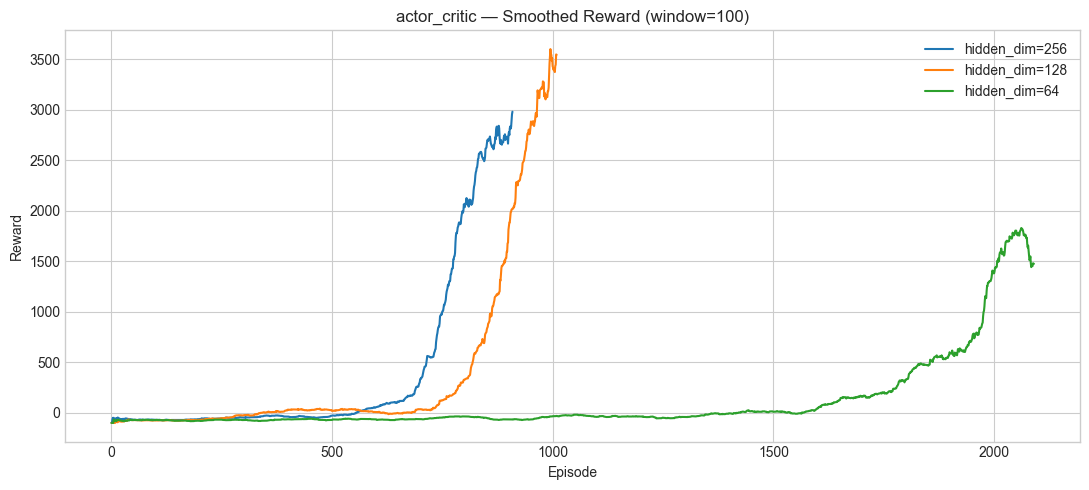

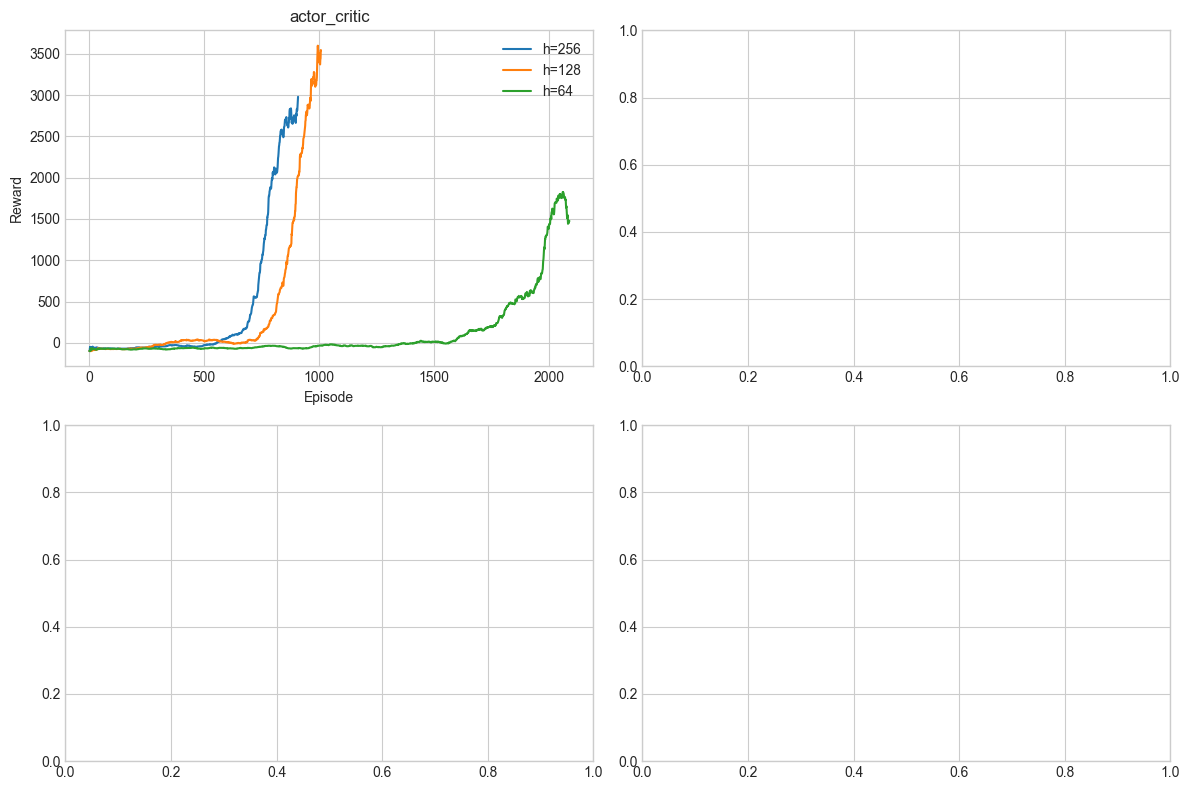

Saved: /Users/vasilij/Documents/RL_proj4/HorizontalPong/readme_nec/hidden_dim_ablation_reward.png


In [3]:
# Reward curves (Actor-Critic only) — compare hidden dims
agent = 'actor_critic'

plt.figure(figsize=(11, 5))
for hidden_dim in HIDDEN_DIMS:
    key = (agent, hidden_dim)
    if key not in results:
        continue
    df = results[key]
    if 'reward' not in df.columns:
        continue
    smooth = df['reward'].rolling(WINDOW, min_periods=1).mean()
    plt.plot(df['episode'], smooth, label=f'hidden_dim={hidden_dim}')

plt.title(f'{agent} — Smoothed Reward (window={WINDOW})')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()
plt.tight_layout()
plt.show()

# Save figure for README
save_path = PROJECT_ROOT / 'readme_nec' / 'dim_comparison_reward.png'
plt.figure(figsize=(11, 5))
for hidden_dim in HIDDEN_DIMS:
    key = (agent, hidden_dim)
    if key not in results:
        continue
    df = results[key]
    smooth = df['reward'].rolling(WINDOW, min_periods=1).mean()
    plt.plot(df['episode'], smooth, label=f'h={hidden_dim}')
plt.title(f'Actor-Critic — Reward (window={WINDOW})')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()
plt.tight_layout()
plt.savefig(save_path, dpi=150)
plt.show()
print(f'Saved: {save_path}')


In [4]:
# Summary table (last 100 episodes)
rows = []
for (agent, hidden_dim), df in sorted(results.items()):
    row = {'agent': agent, 'hidden_dim': hidden_dim, 'episodes': len(df)}
    for col in ['reward', 'hits']:
        if col in df.columns:
            s = df[col].tail(100)
            row[f'last100_{col}_mean'] = s.mean()
            row[f'last100_{col}_std'] = s.std()
    rows.append(row)

summary = pd.DataFrame(rows).sort_values(['agent', 'hidden_dim']).reset_index(drop=True)
display(summary)

# ------------------- Eval (deterministic) -------------------
EVAL_EPISODES = 50
EVAL_SEED = 1233142

# Make sure project root is on PYTHONPATH (notebook may run from analysis/)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from run.eval import evaluate, load_agent
from src.environment.pong_env import PongEnv

metrics_rows = []
for hidden_dim in HIDDEN_DIMS:
    for agent in AGENTS:
        run_dir = BASE_OUTDIR / f'hd_{hidden_dim}' / f'agent_{agent}'
        ckpt = run_dir / f'{agent}_model.pt'
        if not ckpt.exists():
            print(f"[skip eval] missing checkpoint: {ckpt}")
            continue

        env = PongEnv()
        env.seed(EVAL_SEED)
        env.set_random_bounce(True)
        env.set_global_step(200_000)

        agent_obj = load_agent(agent, str(ckpt), device=DEVICE, hidden_dim_override=hidden_dim)
        m = evaluate(env, agent_obj, num_episodes=EVAL_EPISODES, deterministic=True)
        metrics_rows.append({'agent': agent, 'hidden_dim': hidden_dim, **m})
        print(f"[eval] agent={agent:18s} hidden_dim={hidden_dim:3d} mean_reward={m['mean_reward']:.1f} mean_hits={m['mean_hits']:.1f}")

metrics = pd.DataFrame(metrics_rows).sort_values(['agent', 'hidden_dim']).reset_index(drop=True)
display(metrics)

# Save eval table image for README (no extra deps)
fig, ax = plt.subplots(figsize=(10, 2.0 + 0.35 * len(metrics)))
ax.axis('off')

cols = ['agent', 'hidden_dim', 'mean_reward', 'std_reward', 'mean_hits', 'mean_length', 'max_hits']
df_show = metrics[cols].copy() if all(c in metrics.columns for c in cols) else metrics.copy()

# Format numbers for readability
for c in df_show.columns:
    if c in {'mean_reward', 'std_reward', 'mean_hits', 'mean_length', 'max_hits'}:
        df_show[c] = df_show[c].map(lambda x: f"{x:.1f}" if isinstance(x, (int, float)) else x)

_table = ax.table(
    cellText=df_show.values,
    colLabels=df_show.columns,
    cellLoc='center',
    loc='center',
)
_table.auto_set_font_size(False)
_table.set_fontsize(9)
_table.scale(1, 1.3)

save_table = PROJECT_ROOT / 'readme_nec' / 'table_dim_comparison.png'
plt.tight_layout()
plt.savefig(save_table, dpi=200)
plt.show()
print(f"Saved: {save_table}")

# -----------------------------------------------------------


,agent,hidden_dim,episodes,last100_reward_mean,last100_reward_std,last100_hits_mean,last100_hits_std
0,actor_critic,64,2090,1474.0,1531.792375,15.66,15.231692
1,actor_critic,128,1009,3542.0,3485.965513,36.18,34.639669
2,actor_critic,256,909,2979.0,2564.296229,30.60,25.487569


pygame-ce 2.5.7 (SDL 2.32.10, Python 3.14.0)
Loading checkpoint from: /Users/vasilij/Documents/RL_proj4/HorizontalPong/artifacts/hidden_dim_sweep/hd_256/agent_actor_critic/actor_critic_model.pt
[eval] agent=actor_critic       hidden_dim=256 mean_reward=3604.0 mean_hits=37.0
Loading checkpoint from: /Users/vasilij/Documents/RL_proj4/HorizontalPong/artifacts/hidden_dim_sweep/hd_128/agent_actor_critic/actor_critic_model.pt
[eval] agent=actor_critic       hidden_dim=128 mean_reward=7294.0 mean_hits=73.9
Loading checkpoint from: /Users/vasilij/Documents/RL_proj4/HorizontalPong/artifacts/hidden_dim_sweep/hd_64/agent_actor_critic/actor_critic_model.pt
[eval] agent=actor_critic       hidden_dim= 64 mean_reward=2276.0 mean_hits=23.8


,agent,hidden_dim,mean_reward,std_reward,mean_hits,mean_length,max_hits
0,actor_critic,64,2276.0,2422.194047,23.76,2228.26,93.0
1,actor_critic,128,7294.0,6756.342502,73.94,5814.12,291.0
2,actor_critic,256,3604.0,3102.061250,37.04,3132.02,138.0
